# Urban Heat Island Econometric Analysis — Île-de-France
## A Comprehensive Econometric Investigation of Nocturnal Thermal Inequality in Greater Paris

**Target journals:** *Sustainable Cities and Society*, *Landscape and Urban Planning*, *Urban Climate*, *Science of the Total Environment*

---

### Study Overview

This notebook implements a full econometric pipeline to assess the environmental, structural, and sociodemographic drivers of the **Nocturnal Temperature Index (NTI)** across Greater Paris (Île-de-France). Data are derived from ECOSTRESS thermal imagery combined with census, land-use, and topographic covariates. The analysis spans multiple July observations across 2020–2025.

**Analytical roadmap:**
1. Data preparation & descriptive statistics
2. Multicollinearity diagnostics (VIF, correlation)
3. Nested OLS models (A → D) with clustered standard errors
4. Interaction effects (poverty × built environment; income × greenness)
5. Spatial autocorrelation: Moran's I on OLS residuals
6. Spatial lag model (SLM) and Spatial Error model (SEM)
7. Model comparison table (AIC, BIC, R², Moran's I)
8. Robustness: quantile regression at Q10 / Q50 / Q90
9. Publication-quality coefficient plot and maps

---
## 1. Library Imports & Configuration

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats

# ── Modelling ─────────────────────────────────────────────────────────────────
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# ── Spatial ───────────────────────────────────────────────────────────────────
import libpysal
from libpysal.weights import Queen, KNN
from esda.moran import Moran
from spreg import OLS, ML_Lag, ML_Error, GM_Lag, GM_Error

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# Plot aesthetics (publication style)
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Loading & Preparation

In [3]:
# Load spatial data
gdf = gpd.read_file("C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\july_paris_nti.gpkg")
print(f"Dataset shape: {gdf.shape}")
print(f"CRS: {gdf.crs}")
gdf.info()

Dataset shape: (57813, 31)
CRS: EPSG:2154
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 57813 entries, 0 to 57812
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   grid_id                57813 non-null  str     
 1   year                   57813 non-null  int64   
 2   month                  57813 non-null  int32   
 3   early_morning          57813 non-null  float32 
 4   late_night             57813 non-null  float32 
 5   NTI                    57813 non-null  float64 
 6   ndvi                   57813 non-null  float64 
 7   ndbi                   57813 non-null  float64 
 8   dem                    57813 non-null  float64 
 9   DistWater              57813 non-null  float64 
 10  DistWater_log          57813 non-null  float64 
 11  total_dwellings        57809 non-null  float64 
 12  mean_income            57813 non-null  float64 
 13  poverty_rate           57813 non-null  fl

### 2.1 Descriptive Statistics

In [4]:
# Key variables for analysis
all_vars = [
    'NTI', 'ndvi', 'dem', 'DistWater_log', 'pop_density',
    'mean_income', 'poverty_rate', 'share_collective',
    'share_post90', 'share_45_70', 'share_70_90', 'share_pre45',
    'social_share', 'elderly_share', 'child_broad_share',
    'single_parent_share', 'single_person_share'
]

desc = gdf[all_vars].describe().T
desc['skewness'] = gdf[all_vars].skew()
desc['kurtosis'] = gdf[all_vars].kurt()

print("\n=== DESCRIPTIVE STATISTICS ===")
print(desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']].round(3).to_string())


=== DESCRIPTIVE STATISTICS ===
                       count       mean        std       min        25%        50%        75%         max  skewness  kurtosis
NTI                  57813.0      3.628      1.834    -2.836      2.204      3.512      5.161       7.198     0.059    -0.855
ndvi                 57813.0      0.386      0.144    -0.080      0.293      0.383      0.470       0.927     0.311     0.480
dem                  57813.0     65.128     29.795    23.106     42.066     56.144     84.020     185.103     1.217     1.367
DistWater_log        57813.0      7.574      1.142     0.232      6.945      7.739      8.416       9.512    -1.072     1.821
pop_density          57813.0  12052.288  12365.984    25.000   3600.000   7587.500  16812.500  122512.500     1.707     3.389
mean_income          57813.0  28810.415   9748.081  8646.414  21237.916  26914.188  34842.900   79961.300     0.803     0.198
poverty_rate         57813.0      0.145      0.104     0.000      0.073      0.121    

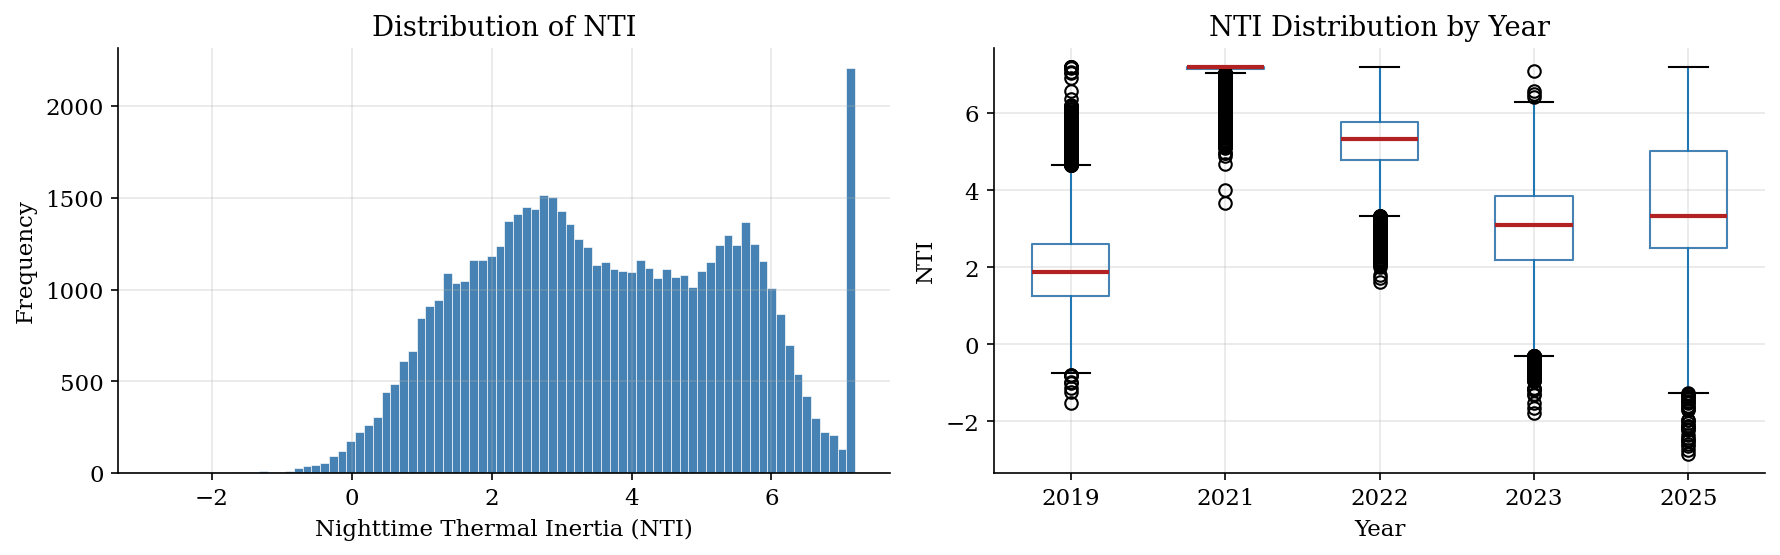

Figure 1 saved.


In [5]:
# Distribution of NTI by year
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NTI distribution
gdf['NTI'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Nighttime Thermal Inertia (NTI)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of NTI')

# NTI by year (boxplot)
gdf.boxplot(column='NTI', by='year', ax=axes[1], 
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='firebrick', linewidth=2))
axes[1].set_xlabel('Year')
axes[1].set_ylabel('NTI')
axes[1].set_title('NTI Distribution by Year')
plt.suptitle('')

plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_resultsfig1_nti_distribution.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 1 saved.")

### 2.2 Standardisation

In [6]:
continuous_vars = [
    'ndvi', 'ndbi', 'dem', 'DistWater', 'DistWater_log', 'total_dwellings',
    'mean_income', 'poverty_rate', 'pop_density', 'share_collective',
    'share_house', 'mean_dwelling_surface', 'large_hh_share', 'share_pre45',
    'share_45_70', 'share_70_90', 'share_post90', 'social_share',
    'elderly_share', 'very_elderly_share', 'child_share',
    'child_broad_share', 'single_parent_share', 'single_person_share'
]

scaler = StandardScaler()
df_std = gdf.copy().dropna()
df_std[continuous_vars] = scaler.fit_transform(df_std[continuous_vars])

# Binary poverty indicator for interaction models
poverty_median = gdf['poverty_rate'].median()
df_std['high_poverty'] = (gdf.loc[df_std.index, 'poverty_rate'] >= poverty_median).astype(int)

# Income tertiles
df_std['income_tertile'] = pd.qcut(
    gdf.loc[df_std.index, 'mean_income'], q=3, labels=['Low','Mid','High']
)

print(f"Analytic sample: {len(df_std):,} observations")
print(f"Years: {sorted(df_std['year'].unique())}")
print(f"High-poverty grid cells: {df_std['high_poverty'].sum():,} ({df_std['high_poverty'].mean()*100:.1f}%)")

Analytic sample: 57,809 observations
Years: [np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2025)]
High-poverty grid cells: 28,906 (50.0%)


---
## 3. Multicollinearity Diagnostics

In [37]:
# VIF for full model predictors
vif_vars = [
    'ndvi', 'dem', 'DistWater_log', 'pop_density',
    'share_post90', 'share_collective', 'share_45_70', 'share_70_90',
    'poverty_rate', 'social_share', 'elderly_share',
    'child_broad_share', 'single_parent_share', 'single_person_share'
]

vif_data = df_std[vif_vars].dropna()
vif_df = pd.DataFrame({
    'Variable': vif_vars,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_vars))]
}).sort_values('VIF', ascending=False)

print("=" * 55)
print("VARIANCE INFLATION FACTORS — Full Model Predictors")
print("=" * 55)
print(vif_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print("\nThresholds: VIF < 5 = acceptable | 5–10 = tolerable | >10 = problematic")

# Flag any issues
problematic = vif_df[vif_df['VIF'] > 10]
if len(problematic) > 0:
    print(f"\n⚠ HIGH VIF (>10): {list(problematic['Variable'])}")
else:
    print("\n✓ No severe multicollinearity detected (all VIF < 10)")

vif_df.to_csv('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\table_vif_full_model.csv', index=False, float_format='%.3f')
print("VIF table exported: table_vif_full_model.csv")

VARIANCE INFLATION FACTORS — Full Model Predictors
           Variable   VIF
   share_collective 3.376
single_person_share 3.037
  child_broad_share 2.330
       social_share 2.032
       share_post90 1.863
      elderly_share 1.822
        share_45_70 1.820
single_parent_share 1.750
               ndvi 1.728
        pop_density 1.653
        share_70_90 1.640
       poverty_rate 1.555
                dem 1.448
      DistWater_log 1.340

Thresholds: VIF < 5 = acceptable | 5–10 = tolerable | >10 = problematic

✓ No severe multicollinearity detected (all VIF < 10)
VIF table exported: table_vif_full_model.csv


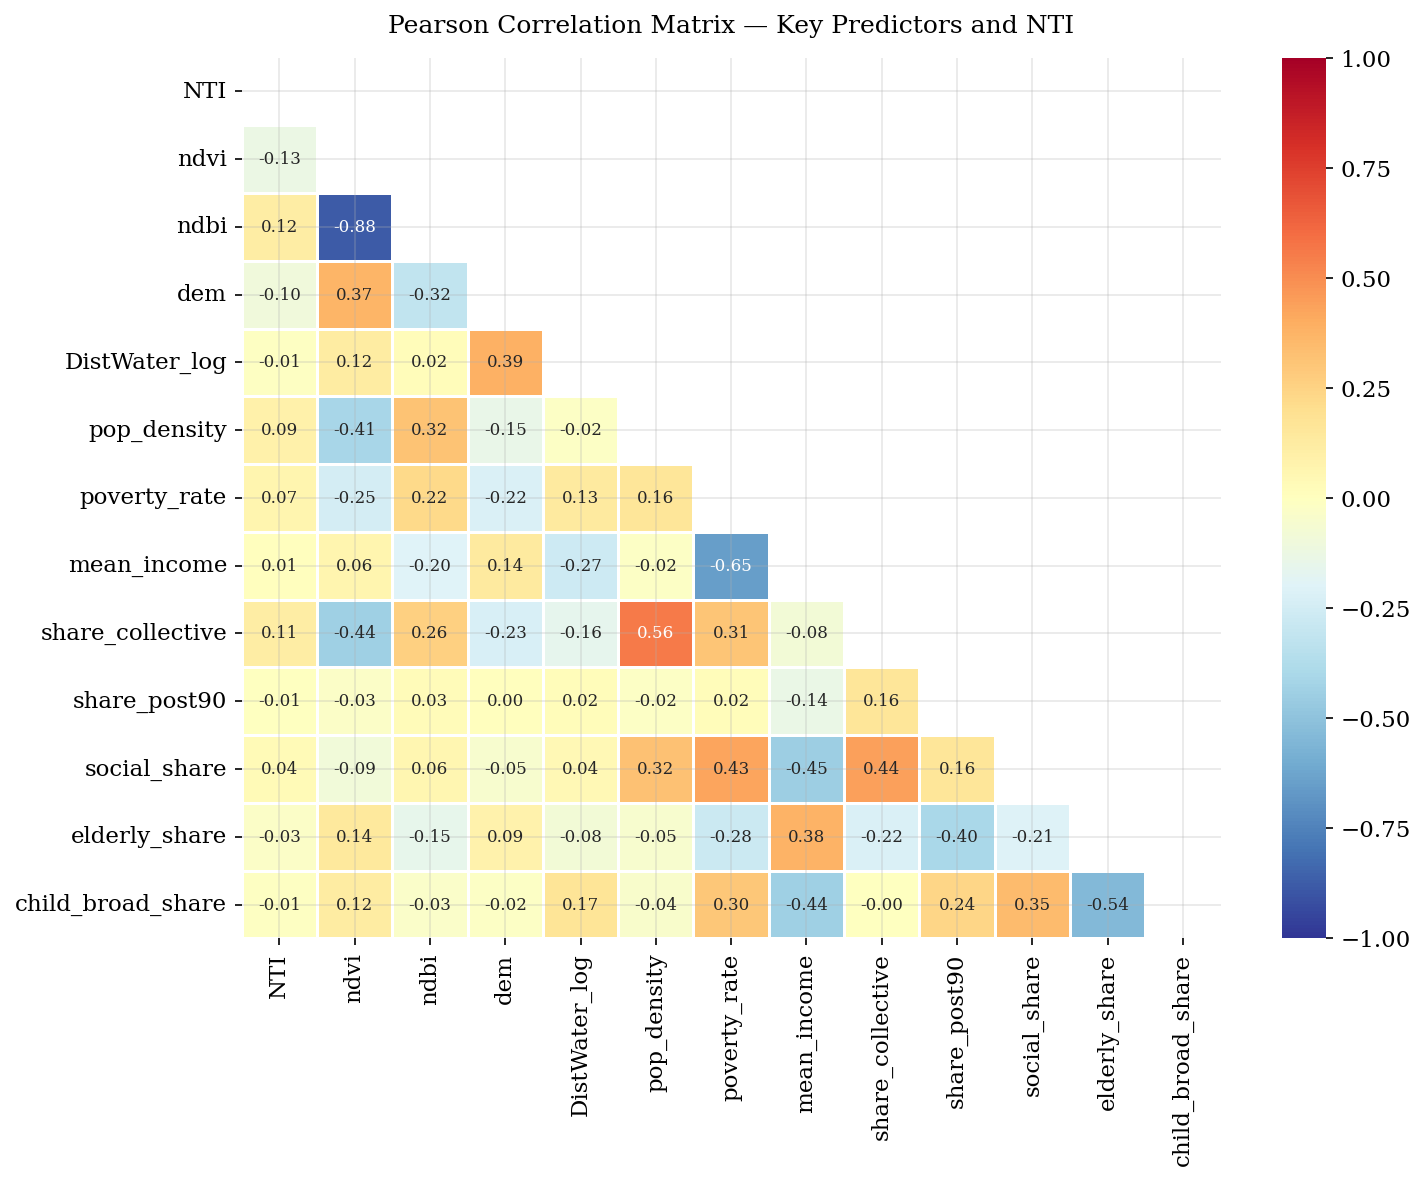

Figure 2 saved.


In [38]:
# Correlation heatmap (publication figure)
core_vars = [
    'NTI', 'ndvi', 'ndbi', 'dem', 'DistWater_log', 'pop_density',
    'poverty_rate', 'mean_income', 'share_collective',
    'share_post90', 'social_share', 'elderly_share', 'child_broad_share'
]
corr_matrix = gdf[core_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix — Key Predictors and NTI', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig2_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 2 saved.")

---
## 4. Nested OLS Models (A → D)

All models use **clustered standard errors** by `grid_id` to account for repeated observations of the same spatial unit across years.

| Model | Block | Variables |
|-------|-------|-----------|
| A | Environmental Physics | NDVI, DEM, DistWater_log + year FE |
| B | + Built Environment | + dwelling age shares, share_collective |
| C | + Sociodemographic Vulnerability | + poverty, social housing, elderly, children, single-parent |
| D | + Mean Income (income-environment channel) | + mean_income |

In [9]:
cluster_kwds = {"groups": df_std["grid_id"]}

# ── Model A: Environmental Physics ────────────────────────────────────────────
model_A = smf.ols(
    "NTI ~ ndvi + dem + DistWater_log + C(year)",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL A — Environmental Physics")
print(model_A.summary())

MODEL A — Environmental Physics
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                 3.618e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -91438.
No. Observations:               57809   AIC:                         1.829e+05
Df Residuals:                   57801   BIC:                         1.830e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept 

In [10]:
# ── Model B: + Built Environment ──────────────────────────────────────────────
model_B = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL B — Environmental Physics + Built Environment")
print(model_B.summary())

MODEL B — Environmental Physics + Built Environment
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                 2.304e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -91023.
No. Observations:               57809   AIC:                         1.821e+05
Df Residuals:                   57797   BIC:                         1.822e+05
Df Model:                          11                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [11]:
# ── Model C: + Sociodemographic Vulnerability ─────────────────────────────────
model_C = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + poverty_rate + social_share + elderly_share
       + child_broad_share + single_parent_share + single_person_share
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL C — + Sociodemographic Vulnerability")
print(model_C.summary())

MODEL C — + Sociodemographic Vulnerability
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                 1.499e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -90983.
No. Observations:               57809   AIC:                         1.820e+05
Df Residuals:                   57791   BIC:                         1.822e+05
Df Model:                          17                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [12]:
# ── Model D: + Mean Income (income-environment channel) ───────────────────────
model_D = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + poverty_rate + social_share + elderly_share
       + child_broad_share + single_parent_share + single_person_share
       + mean_income
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL D — Full Model (+ Income)")
print(model_D.summary())

MODEL D — Full Model (+ Income)
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                 1.439e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -90916.
No. Observations:               57809   AIC:                         1.819e+05
Df Residuals:                   57790   BIC:                         1.820e+05
Df Model:                          18                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
In

---
## 5. Interaction Effects

Testing two theoretically motivated interactions:
1. **Poverty × Built Environment**: Does the effect of collective housing on NTI differ between poor and non-poor areas?
2. **Income × Greenness**: Is the cooling effect of NDVI stronger in wealthier areas (green gentrification hypothesis)?

In [13]:
# ── Model E: Interaction — Poverty × Collective Housing ────────────────────────
model_E = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + poverty_rate + social_share + elderly_share
       + child_broad_share + single_parent_share + single_person_share
       + mean_income
       + poverty_rate:share_collective
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL E — Interaction: Poverty × Collective Housing")
print(model_E.summary())

MODEL E — Interaction: Poverty × Collective Housing
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                 1.366e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -90909.
No. Observations:               57809   AIC:                         1.819e+05
Df Residuals:                   57789   BIC:                         1.820e+05
Df Model:                          19                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [14]:
# ── Model F: Interaction — Income × NDVI (Green Gentrification) ───────────────
model_F = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + poverty_rate + social_share + elderly_share
       + child_broad_share + single_parent_share + single_person_share
       + mean_income
       + mean_income:ndvi
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL F — Interaction: Income × NDVI (Green Gentrification Hypothesis)")
print(model_F.summary())

MODEL F — Interaction: Income × NDVI (Green Gentrification Hypothesis)
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                 1.367e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:41   Log-Likelihood:                -90881.
No. Observations:               57809   AIC:                         1.818e+05
Df Residuals:                   57789   BIC:                         1.820e+05
Df Model:                          19                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [15]:
# ── Model G: Interaction — Pop Density × Distance to Water ───────────────────
model_G = smf.ols(
    """NTI ~ ndvi + dem + DistWater_log
       + share_post90 + share_collective + share_45_70 + share_70_90
       + poverty_rate + social_share + elderly_share
       + child_broad_share + single_parent_share + single_person_share
       + mean_income
       + poverty_rate:share_collective
       + mean_income:ndvi
       + pop_density:DistWater_log
       + C(year)""",
    data=df_std
).fit(cov_type="cluster", cov_kwds=cluster_kwds)
print("MODEL G — Full Interaction Model")
print(model_G.summary())

MODEL G — Full Interaction Model
                            OLS Regression Results                            
Dep. Variable:                    NTI   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                 1.238e+04
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:05:42   Log-Likelihood:                -90864.
No. Observations:               57809   AIC:                         1.818e+05
Df Residuals:                   57787   BIC:                         1.820e+05
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

---
## 6. Model Comparison Summary Table

In [16]:
models = {
    'A: Environmental': model_A,
    'B: + Built Form': model_B,
    'C: + Vulnerability': model_C,
    'D: + Income': model_D,
    'E: + Poverty×Housing': model_E,
    'F: + Income×NDVI': model_F,
    'G: Full Interactions': model_G,
}

summary_rows = []
for name, m in models.items():
    summary_rows.append({
        'Model': name,
        'N': int(m.nobs),
        'R²': round(m.rsquared, 4),
        'Adj. R²': round(m.rsquared_adj, 4),
        'AIC': round(m.aic, 1),
        'BIC': round(m.bic, 1),
        'Log-Lik.': round(m.llf, 1),
        'k': int(m.df_model),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print("=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)
print(summary_df.to_string())
print("\nNote: AIC/BIC based on MLE (not clustered SE). Lower AIC/BIC = better fit.")

MODEL COMPARISON TABLE
                          N      R²  Adj. R²       AIC       BIC  Log-Lik.   k
Model                                                                         
A: Environmental      57809  0.5881   0.5881  182891.9  182963.6  -91437.9   7
B: + Built Form       57809  0.5940   0.5939  182070.1  182177.7  -91023.1  11
C: + Vulnerability    57809  0.5945   0.5944  182002.1  182163.4  -90983.0  17
D: + Income           57809  0.5955   0.5954  181869.5  182039.8  -90915.7  18
E: + Poverty×Housing  57809  0.5956   0.5954  181858.5  182037.8  -90909.3  19
F: + Income×NDVI      57809  0.5960   0.5958  181801.6  181980.9  -90880.8  19
G: Full Interactions  57809  0.5962   0.5961  181771.0  181968.3  -90863.5  21

Note: AIC/BIC based on MLE (not clustered SE). Lower AIC/BIC = better fit.


---
## 7. Publication Coefficient Plot (Models A–D)

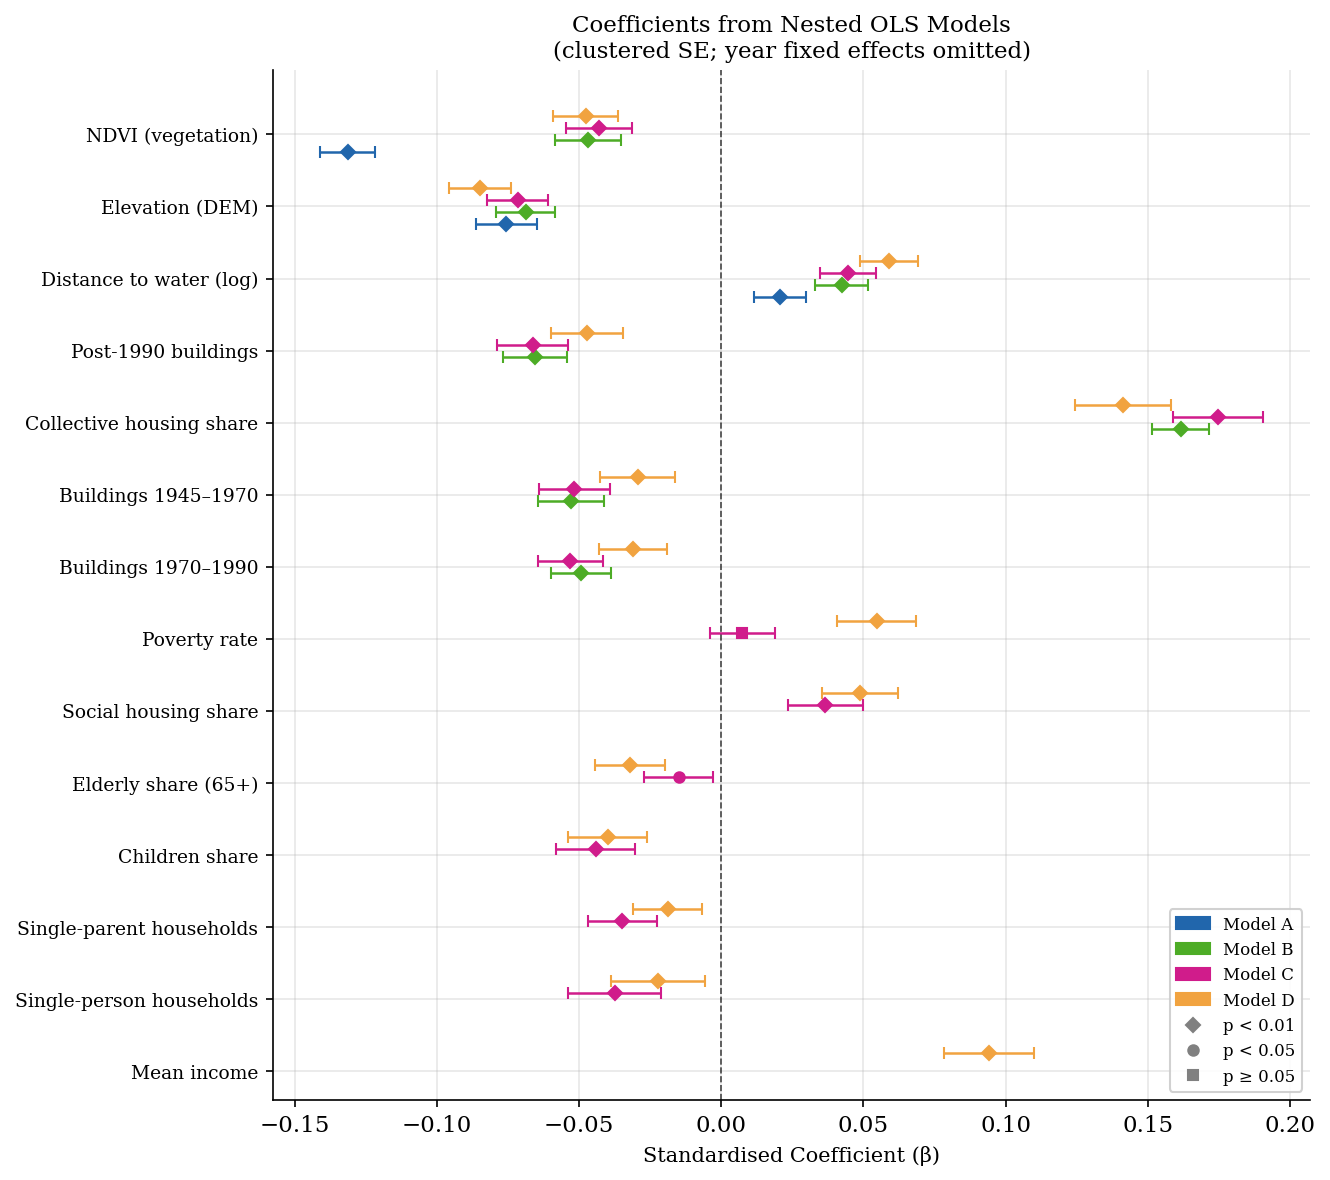

Figure 3 (coefficient plot) saved.


In [17]:
# Variables to include in coefficient plot (excluding year FEs and intercept)
coef_vars = [
    'ndvi', 'dem', 'DistWater_log',
    'share_post90', 'share_collective', 'share_45_70', 'share_70_90',
    'poverty_rate', 'social_share', 'elderly_share',
    'child_broad_share', 'single_parent_share', 'single_person_share',
    'mean_income'
]

var_labels = {
    'ndvi': 'NDVI (vegetation)',
    'dem': 'Elevation (DEM)',
    'DistWater_log': 'Distance to water (log)',
    'share_post90': 'Post-1990 buildings',
    'share_collective': 'Collective housing share',
    'share_45_70': 'Buildings 1945–1970',
    'share_70_90': 'Buildings 1970–1990',
    'poverty_rate': 'Poverty rate',
    'social_share': 'Social housing share',
    'elderly_share': 'Elderly share (65+)',
    'child_broad_share': 'Children share',
    'single_parent_share': 'Single-parent households',
    'single_person_share': 'Single-person households',
    'mean_income': 'Mean income',
}

plot_models = [
    ('A', model_A, '#2166ac'),
    ('B', model_B, '#4dac26'),
    ('C', model_C, '#d01c8b'),
    ('D', model_D, '#f1a340'),
]

fig, ax = plt.subplots(figsize=(9, 8))
offsets = np.linspace(-0.25, 0.25, len(plot_models))

for offset, (label, model, color) in zip(offsets, plot_models):
    params = model.params
    conf = model.conf_int()
    for y_pos, var in enumerate(reversed(coef_vars)):
        if var in params.index:
            coef = params[var]
            lo = conf.loc[var, 0]
            hi = conf.loc[var, 1]
            p = model.pvalues[var]
            marker = 'D' if p < 0.01 else ('o' if p < 0.05 else 's')
            ax.errorbar(
                coef, y_pos + offset,
                xerr=[[coef - lo], [hi - coef]],
                fmt=marker, color=color, ms=5, capsize=3, linewidth=1.2,
                label=f'Model {label}' if y_pos == 0 else '_nolegend_'
            )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(coef_vars)))
ax.set_yticklabels([var_labels.get(v, v) for v in reversed(coef_vars)], fontsize=9)
ax.set_xlabel('Standardised Coefficient (β)', fontsize=10)
ax.set_title('Coefficients from Nested OLS Models\n(clustered SE; year fixed effects omitted)', fontsize=11)

# Legend
handles = [mpatches.Patch(color=c, label=f'Model {l}') for l, _, c in plot_models]
handles += [
    plt.Line2D([0],[0], marker='D', color='grey', ms=5, linestyle='None', label='p < 0.01'),
    plt.Line2D([0],[0], marker='o', color='grey', ms=5, linestyle='None', label='p < 0.05'),
    plt.Line2D([0],[0], marker='s', color='grey', ms=5, linestyle='None', label='p ≥ 0.05'),
]
ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig3_coefficient_plot.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 3 (coefficient plot) saved.")

---
## 8. Spatial Autocorrelation Analysis

### 8.1 Moran's I on OLS Residuals

If OLS residuals are spatially autocorrelated (Moran's I ≠ 0), OLS estimates are inefficient and spatial econometric models are warranted.

In [18]:
# Build Queen contiguity spatial weights matrix
# Use the full geometry-intact GeoDataFrame aligned with df_std
gdf_model = gdf.loc[df_std.index].copy().reset_index(drop=True)
df_model = df_std.reset_index(drop=True)

print("Building Queen contiguity weights matrix... (this may take a moment)")
W_queen = Queen.from_dataframe(gdf_model, silence_warnings=True)
W_queen.transform = 'r'  # row-standardise
print(f"W built: {W_queen.n} units, avg {W_queen.mean_neighbors:.2f} neighbours")

# Moran's I for each model's residuals
moran_results = {}
for name, model in [('A', model_A), ('B', model_B), ('C', model_C), ('D', model_D)]:
    resid = model.resid.values
    mi = Moran(resid, W_queen)
    moran_results[f'Model {name}'] = {
        "Moran's I": round(mi.I, 4),
        'E[I]': round(mi.EI, 4),
        'z-score': round(mi.z_norm, 4),
        'p-value': round(mi.p_norm, 4)
    }
    print(f"Model {name}: Moran's I = {mi.I:.4f}, z = {mi.z_norm:.2f}, p = {mi.p_norm:.4f}")

moran_df = pd.DataFrame(moran_results).T
print("\n=== MORAN'S I TEST ON OLS RESIDUALS ===")
print(moran_df.to_string())
print("\nH₀: Residuals are spatially random. p < 0.05 indicates spatial autocorrelation.")

Building Queen contiguity weights matrix... (this may take a moment)
W built: 57809 units, avg 33.05 neighbours
Model A: Moran's I = 0.1374, z = 127.56, p = 0.0000
Model B: Moran's I = 0.1226, z = 113.84, p = 0.0000
Model C: Moran's I = 0.1210, z = 112.29, p = 0.0000
Model D: Moran's I = 0.1193, z = 110.73, p = 0.0000

=== MORAN'S I TEST ON OLS RESIDUALS ===
         Moran's I  E[I]   z-score  p-value
Model A     0.1374  -0.0  127.5619      0.0
Model B     0.1226  -0.0  113.8392      0.0
Model C     0.1210  -0.0  112.2902      0.0
Model D     0.1193  -0.0  110.7295      0.0

H₀: Residuals are spatially random. p < 0.05 indicates spatial autocorrelation.


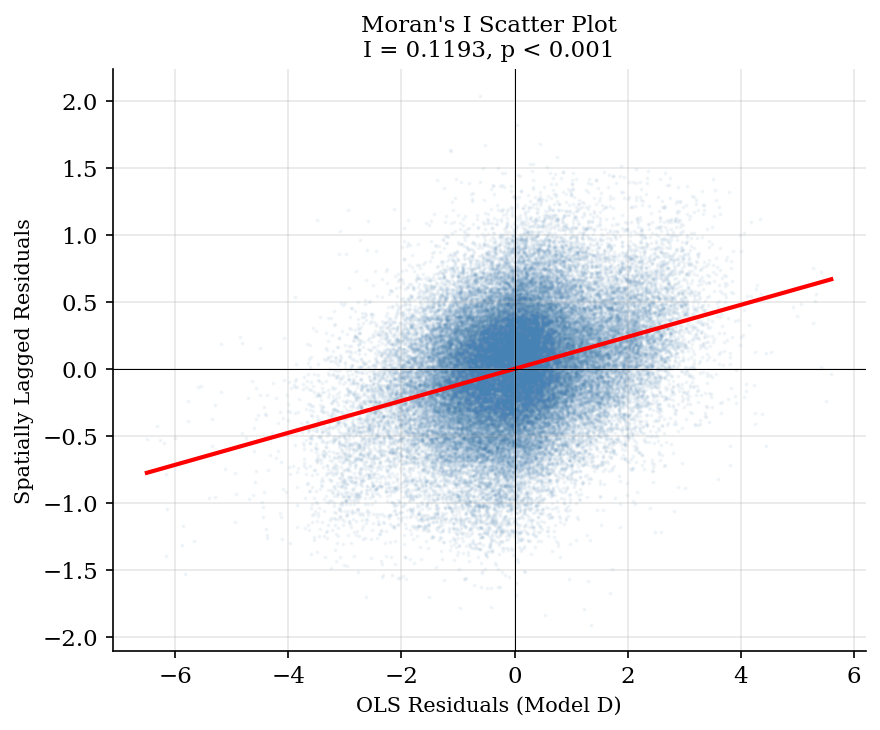

Figure 4 saved.


In [19]:
# Moran scatter plot for Model D residuals
resid_D = model_D.resid.values
mi_D = Moran(resid_D, W_queen)

fig, ax = plt.subplots(figsize=(6, 5))
lag_resid = libpysal.weights.lag_spatial(W_queen, resid_D)

ax.scatter(resid_D, lag_resid, alpha=0.05, s=1, color='steelblue')
# Regression line
z = np.polyfit(resid_D, lag_resid, 1)
p_line = np.poly1d(z)
xline = np.linspace(resid_D.min(), resid_D.max(), 200)
ax.plot(xline, p_line(xline), 'r-', linewidth=2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('OLS Residuals (Model D)', fontsize=10)
ax.set_ylabel('Spatially Lagged Residuals', fontsize=10)
ax.set_title(f"Moran's I Scatter Plot\nI = {mi_D.I:.4f}, p < 0.001", fontsize=11)
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig4_moran_scatter.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 4 saved.")

---
## 9. Spatial Regression Models

Given significant spatial autocorrelation in OLS residuals, we estimate:
- **Spatial Lag Model (SLM)**: NTI = ρWy + Xβ + ε — spatial diffusion / contagion process
- **Spatial Error Model (SEM)**: NTI = Xβ + u; u = λWu + ε — spatially structured omitted variables

Model selection follows the Lagrange Multiplier (LM) test decision rule.

In [20]:
# Prepare numpy arrays for spreg
model_vars = [
    'ndvi', 'dem', 'DistWater_log',
    'share_post90', 'share_collective', 'share_45_70', 'share_70_90',
    'poverty_rate', 'social_share', 'elderly_share',
    'child_broad_share', 'single_parent_share', 'single_person_share',
    'mean_income'
]

# Add year dummies
year_dummies = pd.get_dummies(df_model['year'], prefix='yr', drop_first=True).astype(float)
X_cols = model_vars + list(year_dummies.columns)

X = np.column_stack([
    df_model[model_vars].values,
    year_dummies.values
])
y = df_model['NTI'].values.reshape(-1, 1)

print(f"X shape: {X.shape}, y shape: {y.shape}")

# OLS via spreg (for LM tests)
ols_spreg = OLS(
    y, X,
    w=W_queen,
    name_y='NTI',
    name_x=X_cols,
    spat_diag=True,
    moran=True
)
print(ols_spreg.summary)

X shape: (57809, 18), y shape: (57809, 1)
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :         NTI                Number of Observations:       57809
Mean dependent var  :      3.6276                Number of Variables   :          19
S.D. dependent var  :      1.8336                Degrees of Freedom    :       57790
R-squared           :      0.5955
Adjusted R-squared  :      0.5954
Sum squared residual:     78621.9                F-statistic           :   4726.1263
Sigma-square        :       1.360                Prob(F-statistic)     :           0
S.E. of regression  :       1.166                Log likelihood        :  -90915.733
Sigma-square ML     :       1.360                Akaike info criterion :  181869.465
S.E of regression ML:      1.1662                Schwarz criterion     :  182039.798

------------------

In [21]:
# Lagrange Multiplier tests from OLS diagnostics
print("=" * 55)
print("LAGRANGE MULTIPLIER TESTS (from spreg OLS)")
print("=" * 55)
print(f"LM-Lag:       statistic = {ols_spreg.lm_lag[0]:.4f},  p = {ols_spreg.lm_lag[1]:.4f}")
print(f"LM-Error:     statistic = {ols_spreg.lm_error[0]:.4f}, p = {ols_spreg.lm_error[1]:.4f}")
print(f"RLM-Lag:      statistic = {ols_spreg.rlm_lag[0]:.4f},  p = {ols_spreg.rlm_lag[1]:.4f}")
print(f"RLM-Error:    statistic = {ols_spreg.rlm_error[0]:.4f}, p = {ols_spreg.rlm_error[1]:.4f}")
print("\nDecision rule: If both significant, prefer the larger statistic.")
print("If RLM-Lag > RLM-Error → Spatial Lag preferred; else → Spatial Error preferred.")

LAGRANGE MULTIPLIER TESTS (from spreg OLS)
LM-Lag:       statistic = 8722.3491,  p = 0.0000
LM-Error:     statistic = 12251.1182, p = 0.0000
RLM-Lag:      statistic = 197.3611,  p = 0.0000
RLM-Error:    statistic = 3726.1302, p = 0.0000

Decision rule: If both significant, prefer the larger statistic.
If RLM-Lag > RLM-Error → Spatial Lag preferred; else → Spatial Error preferred.


In [22]:
# ── Spatial Lag Model (ML) ─────────────────────────────────────────────────────
print("Estimating Spatial Lag Model (GMM)...")
slm = GM_Lag(
    y, X,
    w=W_queen,
    name_y='NTI',
    name_x=X_cols,
    name_ds='IDF_UHI'
)
print(slm.summary)

Estimating Spatial Lag Model (GMM)...
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     IDF_UHI
Weights matrix      :     unknown
Dependent Variable  :         NTI                Number of Observations:       57809
Mean dependent var  :      3.6276                Number of Variables   :          20
S.D. dependent var  :      1.8336                Degrees of Freedom    :       57789
Pseudo R-squared    :      0.6190
Spatial Pseudo R-squared:  0.5963

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.99771         0.05817        17.15078         0.00000
                ndvi        -0.02988         0.00618        -4.83772         0.00000
    

In [23]:
# ── Spatial Error Model (ML) ───────────────────────────────────────────────────
print("Estimating Spatial Error Model (ML)...")
sem = GM_Error(
    y, X,
    w=W_queen,
    name_y='NTI',
    name_x=X_cols,
    name_ds='IDF_UHI'
)
print(sem.summary)

Estimating Spatial Error Model (ML)...
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------
Data set            :     IDF_UHI
Weights matrix      :     unknown
Dependent Variable  :         NTI                Number of Observations:       57809
Mean dependent var  :      3.6276                Number of Variables   :          19
S.D. dependent var  :      1.8336                Degrees of Freedom    :       57790
Pseudo R-squared    :      0.5927

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         2.01626         0.01390       145.10304         0.00000
                ndvi        -0.03144         0.00804        -3.90906         0.00009
                 dem        -

---
## 10. Spatial Model Comparison

In [24]:
# Check residual spatial autocorrelation in spatial models
print("=" * 65)
print("SPATIAL MODEL PERFORMANCE COMPARISON")
print("=" * 65)

# OLS
print("\nOLS (spreg):")
print(f"  R²: {ols_spreg.r2:.4f}")
print(f"  AIC: {ols_spreg.aic:.2f}")

# Spatial Lag (GMM)
print("\nSpatial Lag Model (GMM):")
print(f"  ρ (rho):   {slm.rho[0]:.4f}")

# Spatial Error (GMM)
print("\nSpatial Error Model (GMM):")
print("  λ (lambda): not estimated (GMM does not provide lambda)")

# Residual Moran's I
u_slm = y.flatten() - slm.predy.flatten()
u_sem = y.flatten() - sem.predy.flatten()

mi_slm = Moran(u_slm, W_queen)
mi_sem = Moran(u_sem, W_queen)

print(f"\nResidual Moran's I after SLM (GMM): I = {mi_slm.I:.4f}, p = {mi_slm.p_norm:.4f}")
print(f"Residual Moran's I after SEM (GMM): I = {mi_sem.I:.4f}, p = {mi_sem.p_norm:.4f}")

SPATIAL MODEL PERFORMANCE COMPARISON

OLS (spreg):
  R²: 0.5955
  AIC: 181869.47

Spatial Lag Model (GMM):
  ρ (rho):   0.2769

Spatial Error Model (GMM):
  λ (lambda): not estimated (GMM does not provide lambda)

Residual Moran's I after SLM (GMM): I = 0.0564, p = 0.0000
Residual Moran's I after SEM (GMM): I = 0.1303, p = 0.0000


In [25]:
# Full model comparison (OLS + Spatial) — publication table
import pandas as pd
from esda.moran import Moran
import numpy as np

print("=" * 90)
print("TABLE 3: COMPREHENSIVE MODEL COMPARISON — OLS, SPATIAL LAG, SPATIAL ERROR")
print("=" * 90)

all_model_rows = []

# OLS models
for name, model in models.items():
    resid = model.resid.values
    mi = Moran(resid, W_queen)
    all_model_rows.append({
        'Model': name,
        'Type': 'OLS',
        'R²': round(model.rsquared, 4),
        'AIC': round(model.aic, 1),
        'BIC': round(model.bic, 1),
        "Moran's I (resid)": round(mi.I, 4),
        "Moran p": round(mi.p_norm, 4),
        'ρ / λ': '—'
    })

# Spatial Lag (GMM)
resid_slm = y.flatten() - slm.predy.flatten()
mi_slm = Moran(resid_slm, W_queen)
pr2_slm = 1 - np.sum(resid_slm**2) / np.sum((y.flatten() - y.mean())**2)

all_model_rows.append({
    'Model': 'H: Spatial Lag (Model D spec)',
    'Type': 'GMM-Lag',
    'R²': round(pr2_slm, 4),
    'AIC': '—',
    'BIC': '—',
    "Moran's I (resid)": round(mi_slm.I, 4),
    "Moran p": round(mi_slm.p_norm, 4),
    'ρ / λ': round(slm.rho[0], 4)
})

# Spatial Error (GMM)
resid_sem = y.flatten() - sem.predy.flatten()
mi_sem = Moran(resid_sem, W_queen)
pr2_sem = 1 - np.sum(resid_sem**2) / np.sum((y.flatten() - y.mean())**2)

all_model_rows.append({
    'Model': 'I: Spatial Error (Model D spec)',
    'Type': 'GMM-Error',
    'R²': round(pr2_sem, 4),
    'AIC': '—',
    'BIC': '—',
    "Moran's I (resid)": round(mi_sem.I, 4),
    "Moran p": round(mi_sem.p_norm, 4),
    'ρ / λ': '—'  # λ not estimated in GMM
})

comp_df = pd.DataFrame(all_model_rows).set_index('Model')
print(comp_df.to_string())

TABLE 3: COMPREHENSIVE MODEL COMPARISON — OLS, SPATIAL LAG, SPATIAL ERROR
                                      Type      R²       AIC       BIC  Moran's I (resid)  Moran p   ρ / λ
Model                                                                                                     
A: Environmental                       OLS  0.5881  182891.9  182963.6             0.1374      0.0       —
B: + Built Form                        OLS  0.5940  182070.1  182177.7             0.1226      0.0       —
C: + Vulnerability                     OLS  0.5945  182002.1  182163.4             0.1210      0.0       —
D: + Income                            OLS  0.5955  181869.5  182039.8             0.1193      0.0       —
E: + Poverty×Housing                   OLS  0.5956  181858.5  182037.8             0.1190      0.0       —
F: + Income×NDVI                       OLS  0.5960  181801.6  181980.9             0.1175      0.0       —
G: Full Interactions                   OLS  0.5962  181771.0  181968.3

---
## 11. Robustness: Quantile Regression

Quantile regression at Q10 (cool grid cells), Q50 (median), and Q90 (hottest grid cells) tests whether the relationships hold across the **full NTI distribution** — not just the conditional mean. This is essential for identifying whether the poorest, hottest areas face compound disadvantage.

In [26]:
formula_D = """NTI ~ ndvi + dem + DistWater_log
   + share_post90 + share_collective + share_45_70 + share_70_90
   + poverty_rate + social_share + elderly_share
   + child_broad_share + single_parent_share + single_person_share
   + mean_income + C(year)"""

quantile_models = {}
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    qm = smf.quantreg(formula_D, data=df_std).fit(q=q, max_iter=2000)
    quantile_models[q] = qm

    # pseudo-R² manually
    resid = qm.model.endog - qm.fittedvalues
    pseudo_r2 = 1 - np.abs(resid).sum() / np.abs(qm.model.endog - np.median(qm.model.endog)).sum()

    print(f"Q{int(q*100):02d}: pseudo-R² = {pseudo_r2:.4f}, fitted successfully")

Q10: pseudo-R² = 0.0403, fitted successfully
Q25: pseudo-R² = 0.3258, fitted successfully
Q50: pseudo-R² = 0.4362, fitted successfully
Q75: pseudo-R² = 0.2859, fitted successfully
Q90: pseudo-R² = 0.0101, fitted successfully


In [50]:
# Quantile Regression Coefficients ─────────────────────────────────

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

# Variables to include in Table 4
table_vars = [
    'ndvi', 'dem', 'DistWater_log',
    'share_collective', 'share_post90', 'share_45_70', 'share_70_90',
    'poverty_rate', 'social_share', 'elderly_share',
    'child_broad_share', 'single_parent_share', 'single_person_share',
    'mean_income'
]

var_labels = {
    'ndvi':                 'NDVI (vegetation)',
    'dem':                  'Elevation (DEM)',
    'DistWater_log':        'Distance to water (log)',
    'share_collective':     'Collective housing share',
    'share_post90':         'Post-1990 buildings',
    'share_45_70':          'Buildings 1945–1970',
    'share_70_90':          'Buildings 1970–1990',
    'poverty_rate':         'Poverty rate',
    'social_share':         'Social housing share',
    'elderly_share':        'Elderly share (65+)',
    'child_broad_share':    'Children share (broad)',
    'single_parent_share':  'Single-parent households',
    'single_person_share':  'Single-person households',
    'mean_income':          'Mean income',
}

# --- Build coefficient table ---
rows = []
for var in table_vars:
    row = {'Variable': var_labels.get(var, var)}
    for q in quantiles:
        qm = quantile_models[q]
        if var in qm.params.index:
            coef = qm.params[var]
            ci   = qm.conf_int()
            lo   = ci.loc[var].iloc[0]
            hi   = ci.loc[var].iloc[1]
            sig = '*' if (lo > 0 or hi < 0) else ''
            row[f'Q{int(q*100):02d}'] = f"{coef:+.3f}{sig}"
        else:
            row[f'Q{int(q*100):02d}'] = '—'

    # OLS Model D coefficient for comparison
    if var in model_D.params.index:
        coef_ols = model_D.params[var]
        p_ols    = model_D.pvalues[var]
        stars    = '***' if p_ols < 0.001 else '**' if p_ols < 0.01 else '*' if p_ols < 0.05 else ''
        row['OLS (D)'] = f"{coef_ols:+.3f}{stars}"
    else:
        row['OLS (D)'] = '—'

    rows.append(row)

# --- Fit statistics ---
fit_row = {'Variable': 'Pseudo-R²'}
for q in quantiles:
    fit_row[f'Q{int(q*100):02d}'] = f"{quantile_models[q].prsquared:.3f}"
fit_row['OLS (D)'] = f"{model_D.rsquared:.3f}"
rows.append(fit_row)

n_row = {'Variable': 'N'}
for q in quantiles:
    n_row[f'Q{int(q*100):02d}'] = f"{int(quantile_models[q].nobs):,}"
n_row['OLS (D)'] = f"{int(model_D.nobs):,}"
rows.append(n_row)

# --- Print ---
table4 = pd.DataFrame(rows).set_index('Variable')
print("=" * 95)
print("QUANTILE REGRESSION COEFFICIENTS — Dependent Variable: NTI")
print("Standardised coefficients. Year fixed effects included but not shown.")
print("* 95% CI excludes zero.  OLS stars: * p<0.05  ** p<0.01  *** p<0.001")
print("=" * 95)
print(table4.to_string())

#table4.to_csv('table4_quantile_regression.csv')
print("\nExported: table4_quantile_regression.csv")

QUANTILE REGRESSION COEFFICIENTS — Dependent Variable: NTI
Standardised coefficients. Year fixed effects included but not shown.
* 95% CI excludes zero.  OLS stars: * p<0.05  ** p<0.01  *** p<0.001
                              Q10      Q25      Q50      Q75      Q90    OLS (D)
Variable                                                                        
NDVI (vegetation)         -0.070*  -0.045*  -0.033*  -0.031*   -0.003  -0.048***
Elevation (DEM)           -0.097*  -0.161*  -0.141*  -0.074*  -0.025*  -0.085***
Distance to water (log)   +0.074*  +0.081*  +0.090*  +0.064*  +0.028*  +0.059***
Collective housing share  +0.128*  +0.137*  +0.124*  +0.092*  +0.054*  +0.141***
Post-1990 buildings       -0.066*  -0.048*  -0.013*  -0.016*   +0.002  -0.047***
Buildings 1945–1970       -0.048*  -0.027*   +0.006   +0.007  +0.014*  -0.029***
Buildings 1970–1990       -0.062*  -0.045*   -0.009  -0.015*  +0.012*  -0.031***
Poverty rate              +0.033*  +0.040*  +0.059*  +0.050*  +0.059*  +0

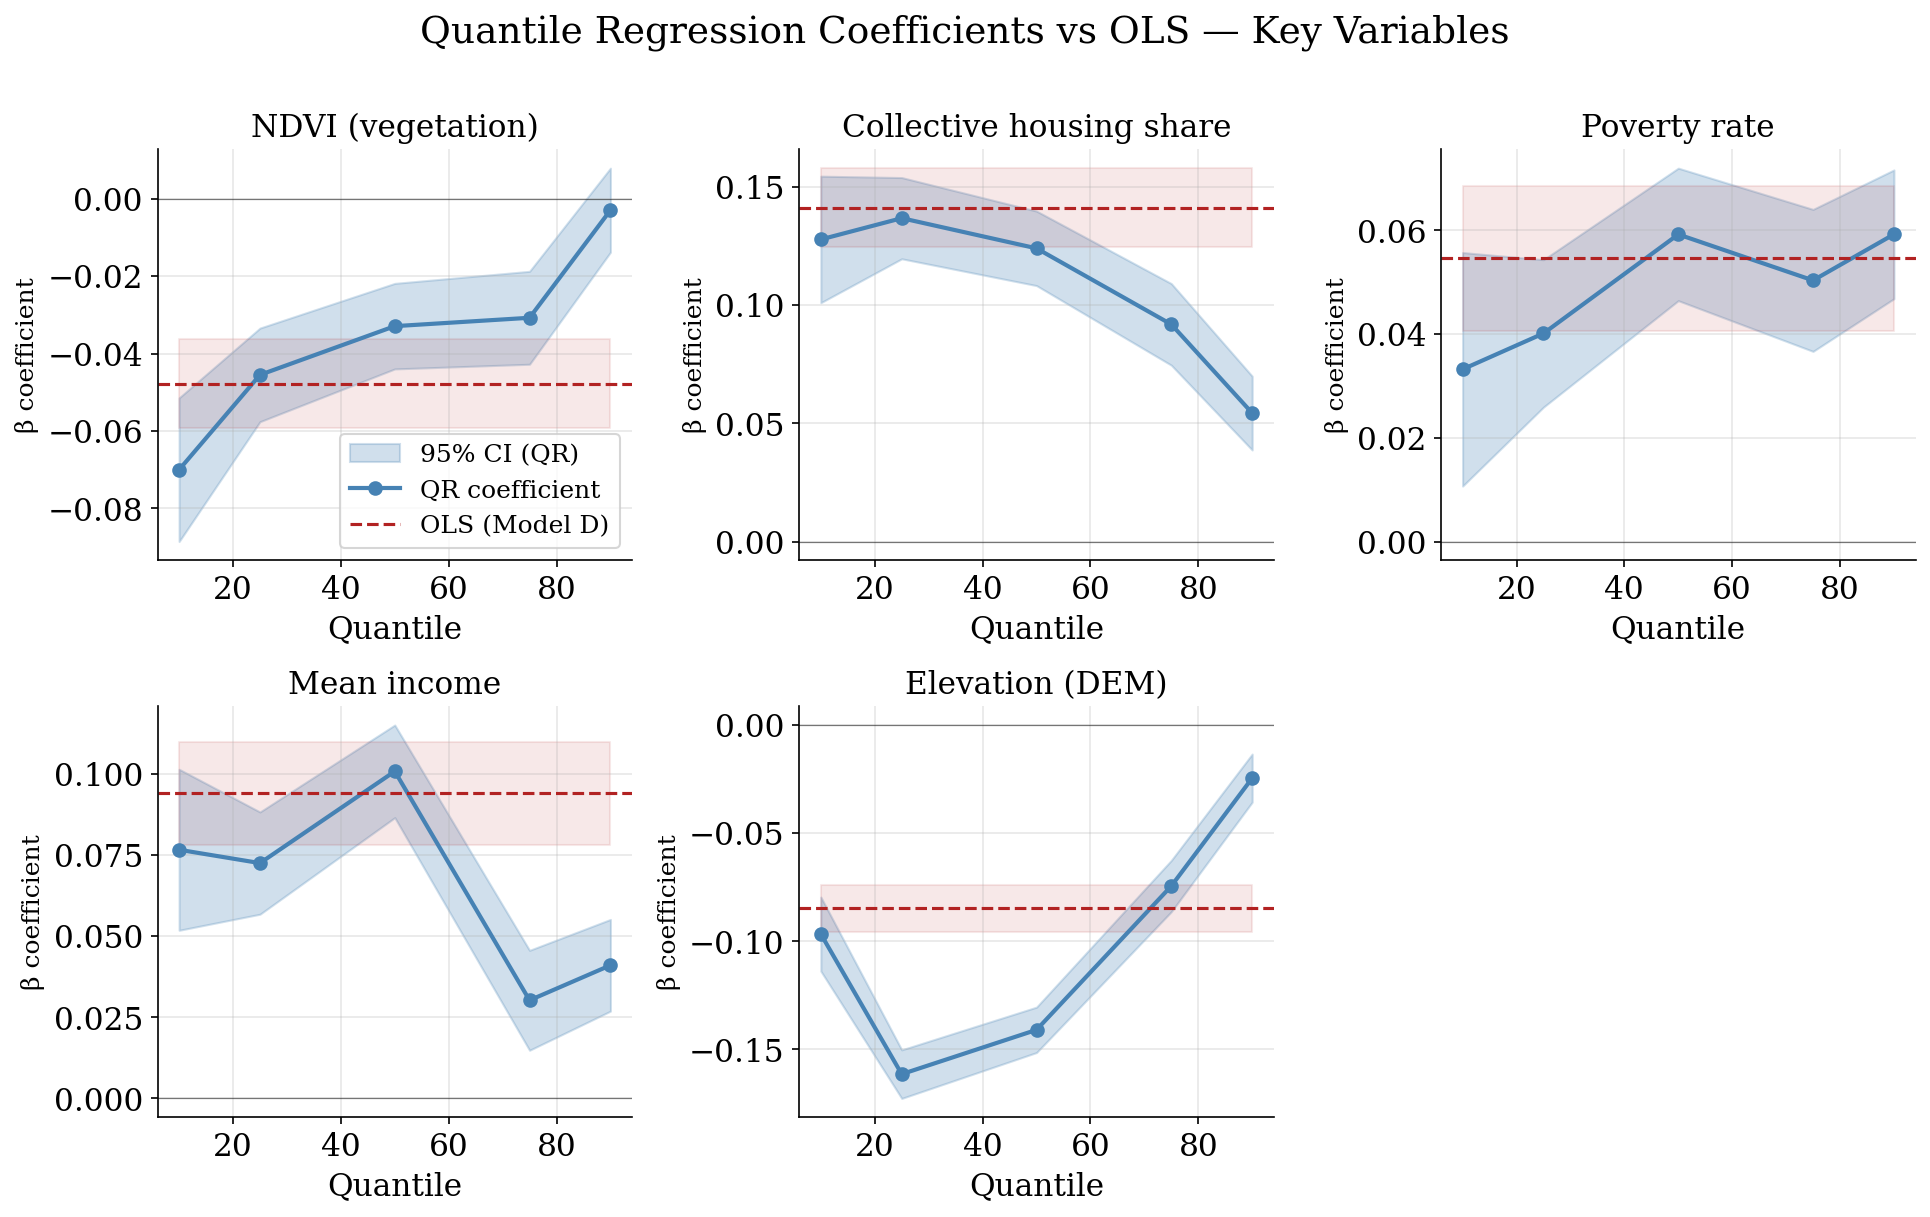

Figure 5 saved.


In [ ]:
# Quantile coefficient plot for key variables
key_vars = ['ndvi', 'share_collective', 'poverty_rate', 'mean_income', 'dem']  # removed 'elderly_share'
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
q_colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
axes = axes.flatten()

for ax_idx, var in enumerate(key_vars):
    coefs = []
    lows = []
    highs = []
    for q in quantiles:
        qm = quantile_models[q]
        if var in qm.params.index:
            ci = qm.conf_int()
            coefs.append(qm.params[var])
            lows.append(ci.loc[var, 0])
            highs.append(ci.loc[var, 1])
        else:
            coefs.append(np.nan)
            lows.append(np.nan)
            highs.append(np.nan)

    ax = axes[ax_idx]
    ols_coef = model_D.params.get(var, np.nan)
    ols_lo = model_D.conf_int().loc[var, 0] if var in model_D.conf_int().index else np.nan
    ols_hi = model_D.conf_int().loc[var, 1] if var in model_D.conf_int().index else np.nan

    ax.fill_between([q*100 for q in quantiles], lows, highs, alpha=0.25, color='steelblue', label='95% CI (QR)')
    ax.plot([q*100 for q in quantiles], coefs, 'o-', color='steelblue', linewidth=2, ms=6, label='QR coefficient')
    ax.axhline(ols_coef, color='firebrick', linewidth=1.5, linestyle='--', label='OLS (Model D)')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.fill_between([10, 90], ols_lo, ols_hi, alpha=0.1, color='firebrick')
    ax.set_title(var_labels.get(var, var), fontsize=15)
    ax.set_xlabel('Quantile', fontsize=15)
    ax.set_ylabel('β coefficient', fontsize=12)
    ax.tick_params(labelsize=15)
    if ax_idx == 0:
        ax.legend(fontsize=12)

# hide any unused axes (one unused when 5 key_vars in 2x3 grid)
for j in range(len(key_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Quantile Regression Coefficients vs OLS — Key Variables', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig5_quantile_regression.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 5 saved.")
# ...existing code...

---
## 12. Spatial Maps — NTI, Residuals, and Key Predictors

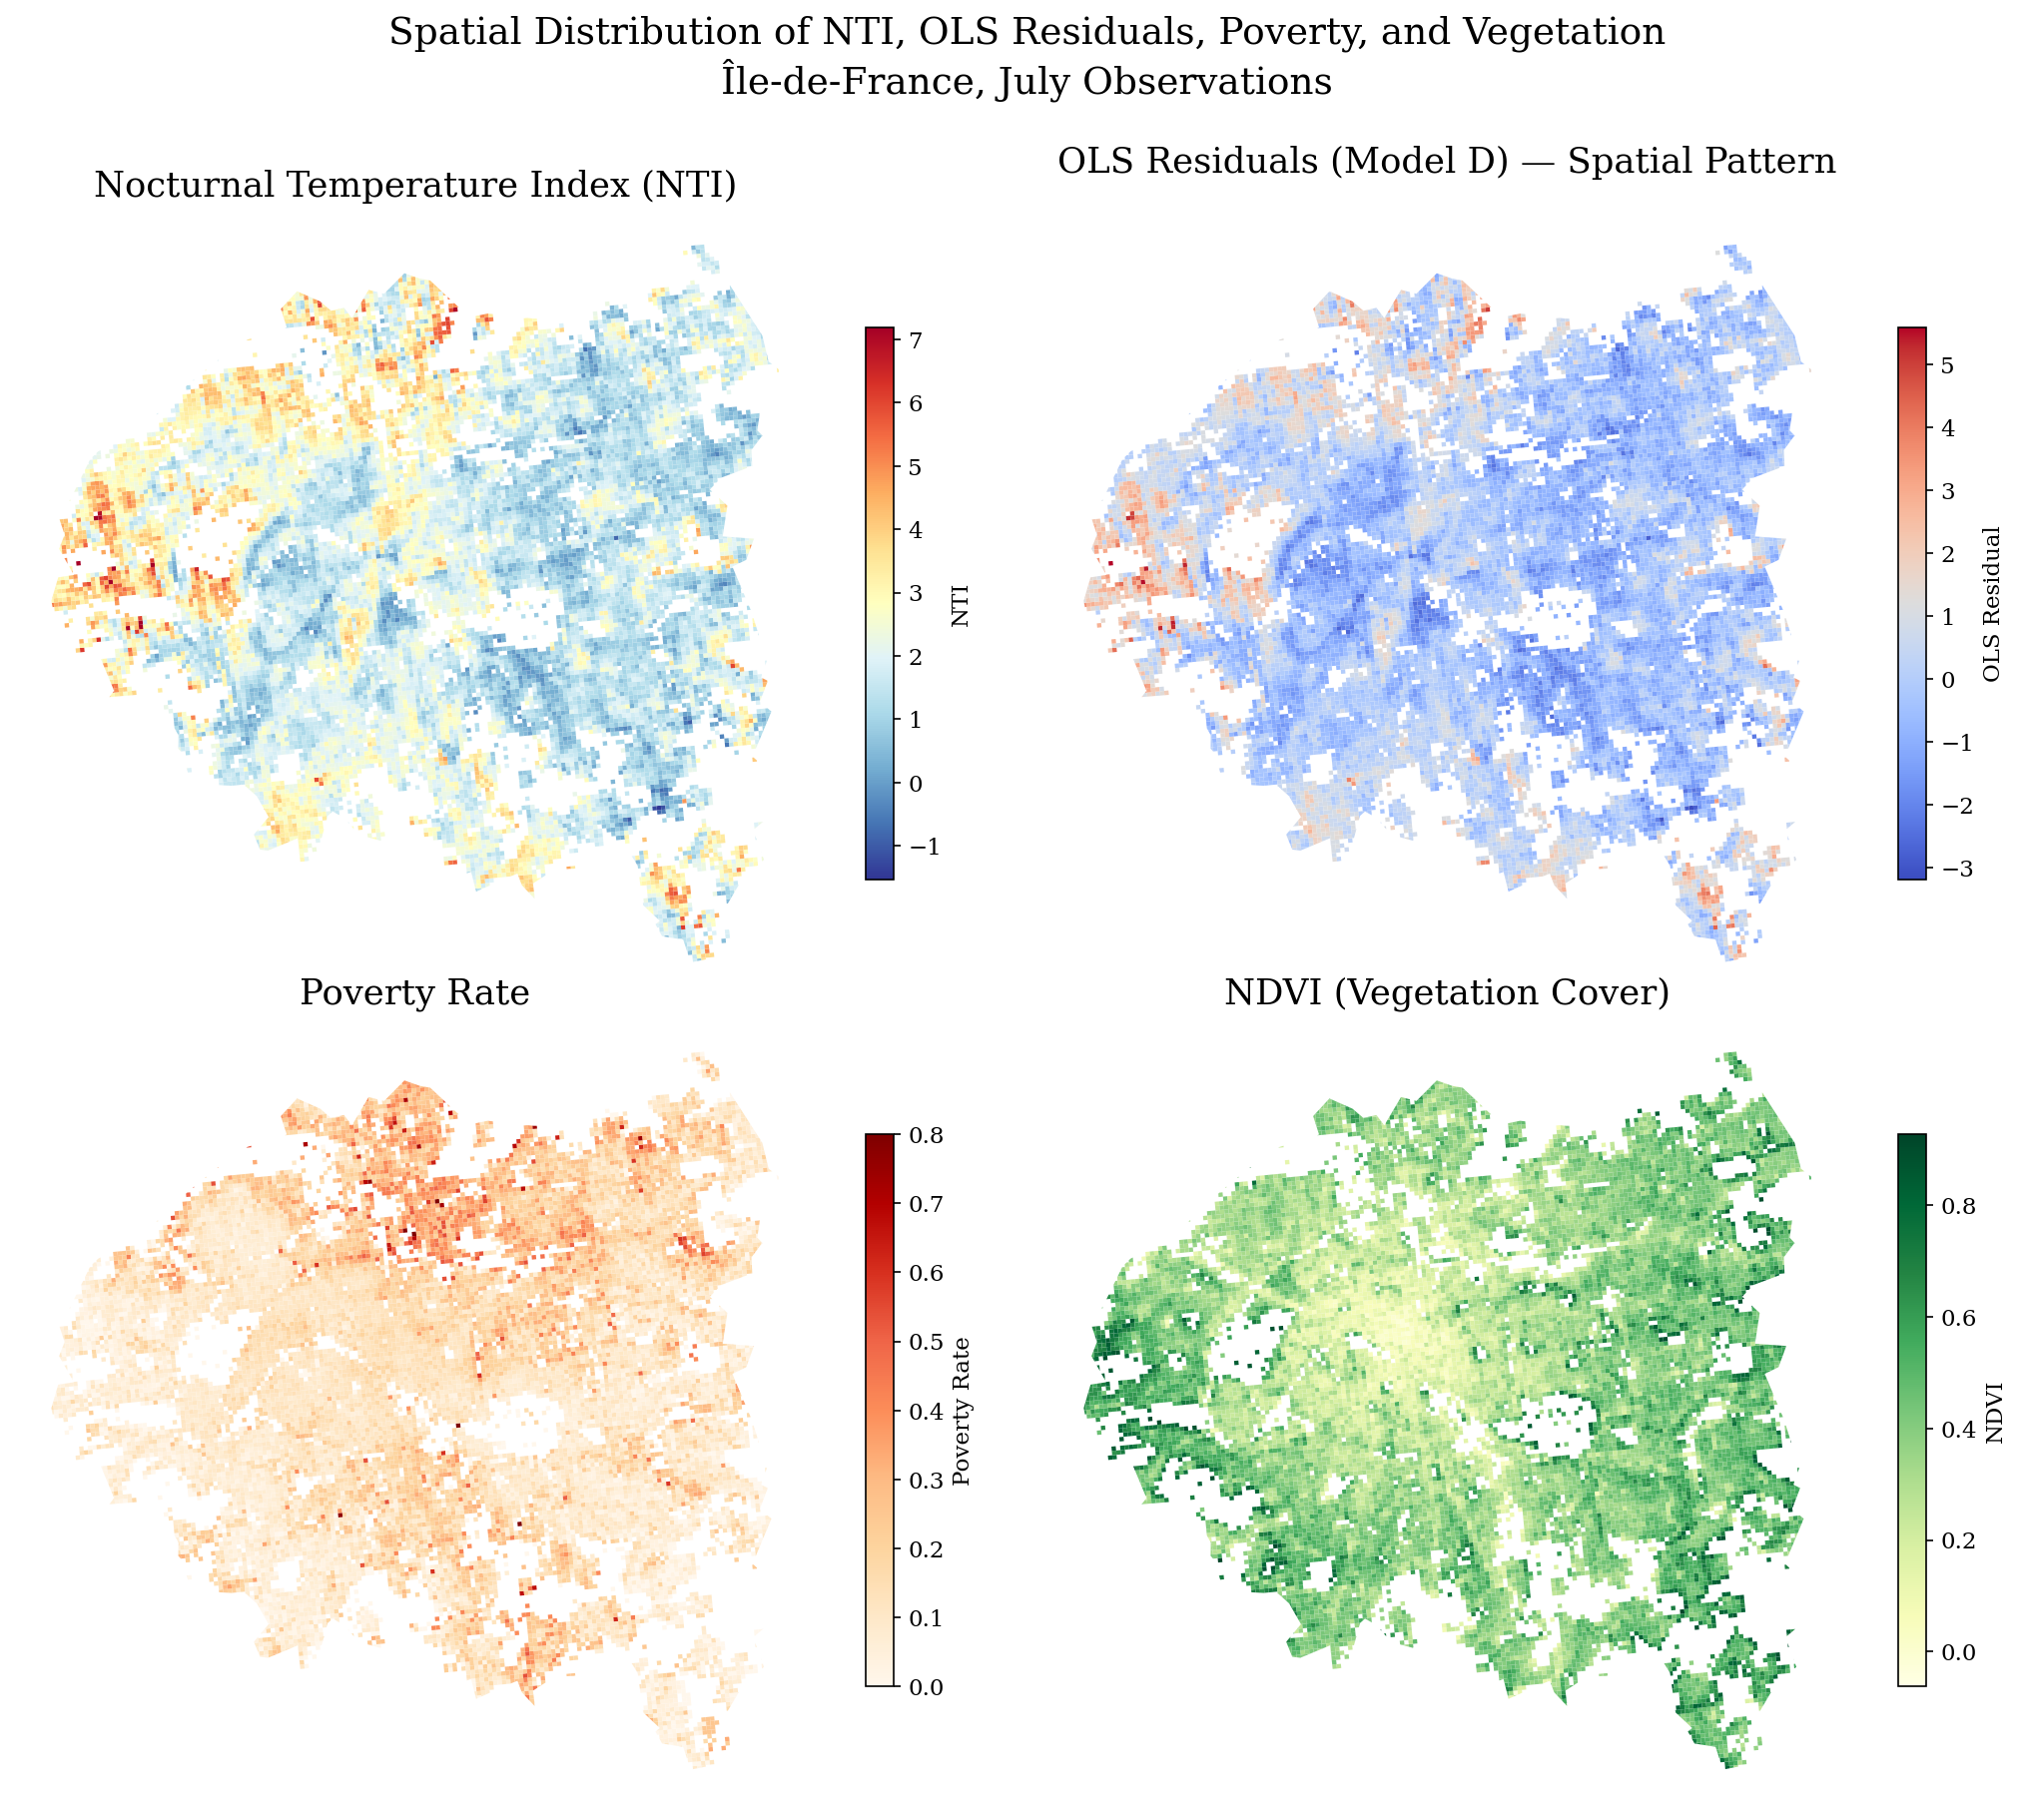

Figure 6 saved.


In [43]:
# Attach model D residuals to spatial dataframe
gdf_plot = gdf_model.copy()
gdf_plot['resid_OLS'] = model_D.resid.values
gdf_plot['NTI'] = df_model['NTI'].values
gdf_plot['poverty_rate_raw'] = gdf.loc[df_std.index, 'poverty_rate'].values
gdf_plot['ndvi_raw'] = gdf.loc[df_std.index, 'ndvi'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# NTI mean per grid cell across years
nti_mean = gdf_plot.groupby(gdf_plot.geometry.apply(lambda g: g.wkt))['NTI'].mean()
gdf_unique = gdf_plot.drop_duplicates(subset=['grid_id'])
gdf_unique.plot(column='NTI', ax=axes[0,0], cmap='RdYlBu_r', legend=True,
                legend_kwds={'label': 'NTI', 'shrink': 0.7}, linewidth=0, edgecolor='none')
axes[0,0].set_title('Nocturnal Temperature Index (NTI)', fontsize=17)
axes[0,0].set_axis_off()

# OLS residuals
gdf_unique_r = gdf_plot.drop_duplicates(subset=['grid_id'])
gdf_plot.drop_duplicates(subset=['grid_id']).plot(
    column='resid_OLS', ax=axes[0,1], cmap='coolwarm', legend=True,
    legend_kwds={'label': 'OLS Residual', 'shrink': 0.7},
    linewidth=0, edgecolor='none'
)
axes[0,1].set_title('OLS Residuals (Model D) — Spatial Pattern', fontsize=17)
axes[0,1].set_axis_off()

# Poverty rate
gdf_plot.drop_duplicates(subset=['grid_id']).plot(
    column='poverty_rate_raw', ax=axes[1,0], cmap='OrRd', legend=True,
    legend_kwds={'label': 'Poverty Rate', 'shrink': 0.7},
    linewidth=0, edgecolor='none'
)
axes[1,0].set_title('Poverty Rate', fontsize=17)
axes[1,0].set_axis_off()

# NDVI
gdf_plot.drop_duplicates(subset=['grid_id']).plot(
    column='ndvi_raw', ax=axes[1,1], cmap='YlGn', legend=True,
    legend_kwds={'label': 'NDVI', 'shrink': 0.7},
    linewidth=0, edgecolor='none'
)
axes[1,1].set_title('NDVI (Vegetation Cover)', fontsize=17)
axes[1,1].set_axis_off()

plt.suptitle('Spatial Distribution of NTI, OLS Residuals, Poverty, and Vegetation\nÎle-de-France, July Observations', 
             fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig6_spatial_maps.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 6 saved.")

---
## 13. Interannual Variability Analysis

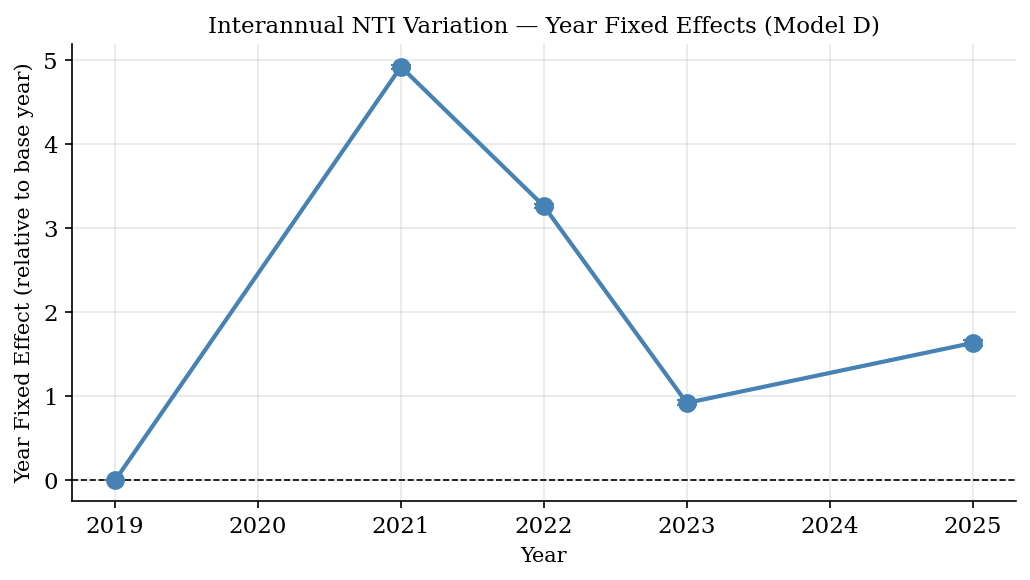

Year fixed effects (NTI units above/below base year):
       coef
2019  0.000
2021  4.915
2022  3.259
2023  0.920
2025  1.633


In [29]:
# Year fixed effects — extract and plot
year_fe = {}
for col in model_D.params.index:
    if 'C(year)' in col:
        yr = int(col.split('[T.')[1].replace(']',''))
        year_fe[yr] = {
            'coef': model_D.params[col],
            'lo': model_D.conf_int().loc[col, 0],
            'hi': model_D.conf_int().loc[col, 1]
        }

# Add base year (2020)
base_year = sorted(df_std['year'].unique())[0]
year_fe[base_year] = {'coef': 0, 'lo': 0, 'hi': 0}
yfe_df = pd.DataFrame(year_fe).T.sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    yfe_df.index, yfe_df['coef'],
    yerr=[yfe_df['coef'] - yfe_df['lo'], yfe_df['hi'] - yfe_df['coef']],
    fmt='o-', color='steelblue', capsize=5, linewidth=2, ms=8
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Year Fixed Effect (relative to base year)', fontsize=10)
ax.set_title('Interannual NTI Variation — Year Fixed Effects (Model D)', fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\fig7_year_effects.png', bbox_inches='tight', dpi=300)
plt.show()

print("Year fixed effects (NTI units above/below base year):")
print(yfe_df[['coef']].round(3).to_string())

---
## 14. Final Summary: Publication-Ready Results Table

In [39]:
def make_results_table(models_dict, vars_of_interest):
    """Generate a publication-style regression table."""
    rows = []
    for var in vars_of_interest:
        row = {'Variable': var_labels.get(var, var)}
        for name, m in models_dict.items():
            if var in m.params.index:
                coef = m.params[var]
                pval = m.pvalues[var]
                se = m.bse[var]
                stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                row[name] = f"{coef:.3f}{stars}\n({se:.3f})"
            else:
                row[name] = '—'
        rows.append(row)

    # Add interaction terms for Models E, F, G
    interaction_terms = ['poverty_rate:share_collective', 'mean_income:ndvi', 'pop_density:DistWater_log']
    interaction_labels = {
        'poverty_rate:share_collective': 'Poverty × Collective Housing',
        'mean_income:ndvi': 'Income × NDVI',
        'pop_density:DistWater_log': 'Pop Density × Distance to Water'
    }
    
    for interact_var in interaction_terms:
        row = {'Variable': interaction_labels.get(interact_var, interact_var)}
        for name, m in models_dict.items():
            if interact_var in m.params.index:
                coef = m.params[interact_var]
                pval = m.pvalues[interact_var]
                se = m.bse[interact_var]
                stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
                row[name] = f"{coef:.3f}{stars}\n({se:.3f})"
            else:
                row[name] = '—'
        rows.append(row)

    # Add fit statistics
    rows.append({'Variable': ''})
    r2_row = {'Variable': 'R²'}
    aic_row = {'Variable': 'AIC'}
    n_row = {'Variable': 'N'}
    for name, m in models_dict.items():
        r2_row[name] = f"{m.rsquared:.3f}"
        aic_row[name] = f"{m.aic:.0f}"
        n_row[name] = f"{int(m.nobs):,}"
    rows.extend([r2_row, aic_row, n_row])

    return pd.DataFrame(rows).set_index('Variable')

core_models = {
    'Model A': model_A,
    'Model B': model_B,
    'Model C': model_C,
    'Model D': model_D,
    'Model E': model_E,
    'Model F': model_F,
    'Model G': model_G,
}

pub_vars = [
    'ndvi', 'dem', 'DistWater_log',
    'share_post90', 'share_collective', 'share_45_70', 'share_70_90',
    'poverty_rate', 'social_share', 'elderly_share',
    'child_broad_share', 'single_parent_share', 'single_person_share',
    'mean_income'
]

results_table = make_results_table(core_models, pub_vars)
print("=" * 140)
print("TABLE 2: REGRESSION RESULTS — Dependent variable: NTI")
print("Standardised coefficients. Clustered SE in parentheses. Year FEs included but not shown.")
print("Significance: * p<0.05, ** p<0.01, *** p<0.001")
print("=" * 140)
print(results_table.to_string())

TABLE 2: REGRESSION RESULTS — Dependent variable: NTI
Standardised coefficients. Clustered SE in parentheses. Year FEs included but not shown.
Significance: * p<0.05, ** p<0.01, *** p<0.001
                                            Model A             Model B             Model C             Model D             Model E             Model F             Model G
Variable                                                                                                                                                                   
NDVI (vegetation)                -0.131***\n(0.005)  -0.047***\n(0.006)  -0.043***\n(0.006)  -0.048***\n(0.006)  -0.047***\n(0.006)  -0.060***\n(0.006)  -0.059***\n(0.006)
Elevation (DEM)                  -0.076***\n(0.005)  -0.069***\n(0.005)  -0.072***\n(0.005)  -0.085***\n(0.006)  -0.084***\n(0.006)  -0.089***\n(0.006)  -0.090***\n(0.006)
Distance to water (log)           0.021***\n(0.005)   0.042***\n(0.005)   0.045***\n(0.005)   0.059***\n(0.005)   0.058***

In [40]:
# Export results table to CSV for inclusion in manuscript
results_table.to_csv('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\table2_regression_results.csv')
comp_df.to_csv('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\table3_model_comparison.csv')
moran_df.to_csv('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\table_moran_tests.csv')
desc.to_csv('C:\\Users\\kbonsu\\Desktop\\AICC Conference\\ECOSTRESS_data_processing\\output\\publishing_results\\table1_descriptive_stats.csv')

print("All tables exported:")
print("  table1_descriptive_stats.csv")
print("  table2_regression_results.csv")
print("  table3_model_comparison.csv")
print("  table_moran_tests.csv")
print("\nAll figures saved as high-resolution PNG (300 dpi):")
for i, f in enumerate(['fig1_nti_distribution', 'fig2_correlation_heatmap', 
                        'fig3_coefficient_plot', 'fig4_moran_scatter',
                        'fig5_quantile_regression', 'fig6_spatial_maps',
                        'fig7_year_effects'], 1):
    print(f"  {f}.png")

All tables exported:
  table1_descriptive_stats.csv
  table2_regression_results.csv
  table3_model_comparison.csv
  table_moran_tests.csv

All figures saved as high-resolution PNG (300 dpi):
  fig1_nti_distribution.png
  fig2_correlation_heatmap.png
  fig3_coefficient_plot.png
  fig4_moran_scatter.png
  fig5_quantile_regression.png
  fig6_spatial_maps.png
  fig7_year_effects.png


---
## 15. Interpretation Guide for Manuscript

### Key findings to report:

**Environmental drivers (Models A–D):**
- NDVI exerts a consistent **cooling effect** on NTI (negative β across all models and quantiles), supporting the urban greening–cooling hypothesis.
- Higher elevation is associated with lower NTI — topographic shading and temperature lapse.
- Distance to water has a positive association with NTI, indicating proximity to water bodies provides a cooling buffer.

**Built environment (Model B–D):**
- `share_collective` (collective housing / apartment blocks) is the strongest positive predictor, consistent with dense built mass retaining heat.
- Older building stock (1945–1990) is associated with **lower** NTI, possibly reflecting larger plot sizes, courtyards, or pre-sprawl urban morphology.
- Post-1990 buildings reduce NTI, potentially reflecting improved insulation standards.

**Sociodemographic vulnerability (Model C–D):**
- `poverty_rate` effect — compare sign and significance across quantiles: does it intensify in the upper tail (Q90), indicating compound thermal disadvantage for the poorest?
- `elderly_share` — negative association with NTI may reflect residential sorting (elderly in greener, cooler suburban areas).
- `single_parent_share` — a robust negative association, possibly reflecting selection into cooler but underserved housing.

**Interaction effects (Models E–F):**
- Poverty × collective housing: test whether the thermal penalty of collective housing is larger in poor areas → evidence for **environmental justice**.
- Income × NDVI: test whether green cooling is unequally distributed — if positive, wealthier areas may benefit less from greening (or already have it).

**Spatial econometrics (Models H–I):**
- Significant Moran's I in OLS residuals confirms spatial dependence — spatial models are justified.
- Report ρ (SLM) or λ (SEM) — the larger AIC improvement indicates which process dominates.
- If residuals after SEM/SLM are no longer significant, spatial models are sufficient.

**Quantile regression:**
- If coefficients grow in magnitude at Q90 vs Q10, the hottest grid cells face disproportionately stronger effects — relevant for heatwave vulnerability policy.

### Suggested journal framing:
> *Sustainable Cities and Society* (Elsevier) — direct fit for urban heat, equity, and built environment
> *Urban Climate* (Elsevier) — methodological focus on spatial econometrics and ECOSTRESS data
> *Landscape and Urban Planning* — if the greenness / NDVI framing is central
> *Science of the Total Environment* — if the vulnerability/justice angle is prominent